# Option Pricing – Black-Scholes Framework

## Objective
- Implement the Black-Scholes model
- Compare option price and payoff
- Visualize time value
- Verify put-call parity


In [8]:

from option_tools import (
    d1, d2, bs_price, payoff, parity_rhs,
    delta, gamma, vega, theta, rho
)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


## Black-Scholes Model Assumptions

The Black-Scholes framework relies on the following assumptions:

- The underlying asset price follows a log-normal distribution.
- Log-returns are normally distributed.
- Volatility \( \sigma \) is constant over time.
- The risk-free interest rate \( r \) is constant.
- The dividend yield \( q \) is constant.
- Trading is continuous.
- No transaction costs or taxes.
- The underlying can be short-sold.
- Securities are perfectly divisible.

Under these assumptions, a closed-form solution exists for European option pricing.

## European Option Pricing

The price of a European option depends on:

- Spot price \( S \)
- Strike price \( K \)
- Time to maturity \( T \)
- Volatility \( \sigma \)
- Risk-free rate \( r \)
- Dividend yield \( q \)

Define:

$$
d_1 = \frac{\ln(S/K) + (r - q + \frac{1}{2}\sigma^2)T}{\sigma \sqrt{T}}
$$

$$
d_2 = d_1 - \sigma \sqrt{T}
$$

Call price:

$$
C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)
$$

Put price:

$$
P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)
$$

where $N(\cdot)$ is the cumulative distribution function of the standard normal distribution.

Under risk-neutral valuation, the expected return of the underlying does not appear in the pricing formula.

## Model Parameters

We define the option and market parameters used throughout the analysis.

In [10]:
K = 100
T = 1.0
r = 0.02
q = 0.0
sigma = 0.2

S = np.linspace(0.01, 200, 1001)

## Option Pricing

We compute the Black-Scholes prices for both call and put options,
and compare them to their intrinsic values.

In [11]:
C = bs_price(S, K, T, r, sigma, q=q, option="call")
P = bs_price(S, K, T, r, sigma, q=q, option="put")

C_pay = payoff(S, K, "call")
P_pay = payoff(S, K, "put")

## Price vs Payoff

The following graphs compare the Black-Scholes price with the option payoff at maturity.

The shaded area represents the time value of the option.

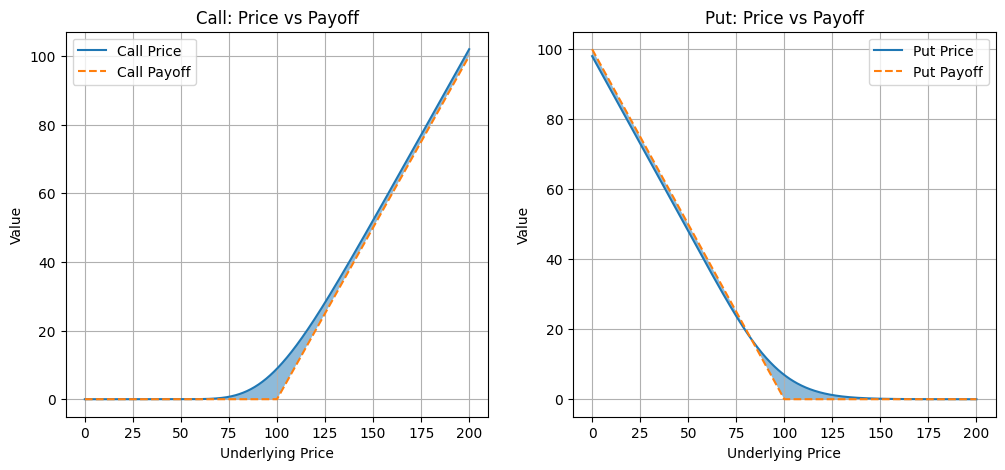

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(S, C, label="Call Price")
plt.plot(S, C_pay, "--", label="Call Payoff")
plt.fill_between(S, np.minimum(C, C_pay), np.maximum(C, C_pay), alpha = 0.5)
plt.title("Call: Price vs Payoff")
plt.xlabel("Underlying Price")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(S, P, label="Put Price")
plt.plot(S, P_pay, "--", label="Put Payoff")
plt.fill_between(S, np.minimum(P, P_pay), np.maximum(P, P_pay), alpha = 0.5)
plt.title("Put: Price vs Payoff")
plt.xlabel("Underlying Price")
plt.ylabel("Value")
plt.legend()
plt.grid(True)


plt.show()

## Time Value Analysis

The time value of an option is defined as:

$$
\text{Time Value} = \text{Option Price} - \text{Intrinsic Value}
$$

From the graph, several important observations can be made:

- The time value is maximal when the option is **at-the-money** (\( S \approx K \)).
- Deep in-the-money and deep out-of-the-money options have lower time value.
- As maturity approaches, the time value converges to zero.
- The peak around \( S = K \) reflects maximum uncertainty about the final payoff.

This confirms that optionality is most valuable when the outcome is uncertain.

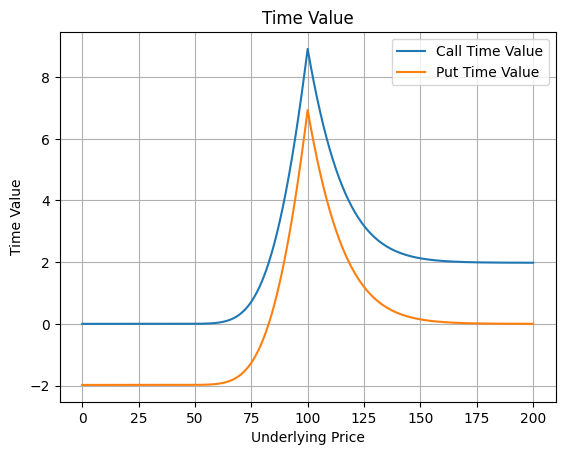

Call time value max at S = 100.01
Put time value max at S = 100.01


In [13]:
TV_call = C - C_pay
TV_put  = P - P_pay

plt.figure()
plt.plot(S, TV_call, label="Call Time Value")
plt.plot(S, TV_put, label="Put Time Value")
plt.title("Time Value")
plt.xlabel("Underlying Price")
plt.ylabel("Time Value")
plt.legend()
plt.grid(True)
plt.show()

print("Call time value max at S =", round(S[np.argmax(TV_call)], 2))
print("Put time value max at S =", round(S[np.argmax(TV_put)], 2))

## Put-Call Parity

Put-call parity defines a model-independent relationship between European call and put options
with the same strike \(K\) and maturity \(T\).

$$
C(K,T) - P(K,T) = S_0 e^{-qT} - K e^{-rT}
$$

This equality must always hold to prevent arbitrage opportunities.


$$
C(K,T) - P(K,T) = \text{Forward}(K,T)
$$



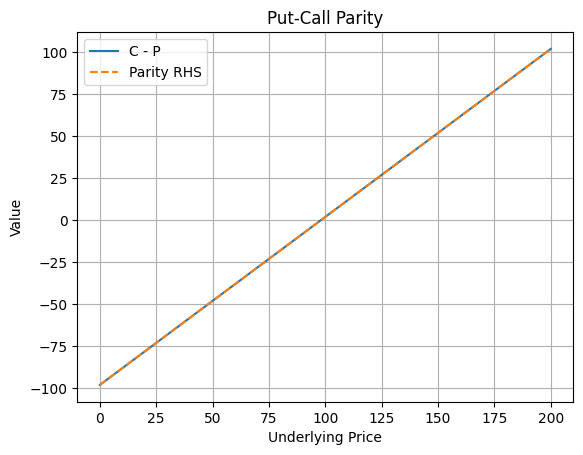

In [14]:
plt.figure()
plt.plot(S, C - P, label="C - P")
plt.plot(S, parity_rhs(S, K, T, r, q=q), "--", label="Parity RHS")
plt.title("Put-Call Parity")
plt.xlabel("Underlying Price")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()